In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU yok. Runtime > Change runtime type > GPU sec.")

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

matches = list(Path("/content/drive/MyDrive").rglob("processed_dataset_v4.zip"))

print("Bulunan dosya sayisi:", len(matches))

for m in matches:
    print(m)

if len(matches) == 0:
    raise FileNotFoundError("processed_dataset_v4.zip Drive icinde bulunamadi.")

ZIP_PATH = matches[0]

print("Kullanilacak ZIP_PATH:", ZIP_PATH)
print("Zip var mi:", ZIP_PATH.exists())

Bulunan dosya sayisi: 1
/content/drive/MyDrive/processed_dataset_v4.zip
Kullanilacak ZIP_PATH: /content/drive/MyDrive/processed_dataset_v4.zip
Zip var mi: True


In [ ]:
import shutil
import zipfile
from pathlib import Path

DATA_ROOT = Path("/content/data_v4")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if DATA_ROOT.exists():
    shutil.rmtree(DATA_ROOT)

DATA_ROOT.mkdir(parents=True, exist_ok=True)

extracted_count = 0
skipped_count = 0

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    for member in zip_ref.infolist():
        fixed_name = member.filename.replace("\\", "/").strip("/")

        if not fixed_name or fixed_name.startswith("/") or ".." in fixed_name:
            skipped_count += 1
            continue

        source_path = Path(fixed_name)

        if source_path.suffix.lower() not in IMAGE_EXTENSIONS:
            skipped_count += 1
            continue

        target_path = DATA_ROOT / source_path
        target_path.parent.mkdir(parents=True, exist_ok=True)

        with zip_ref.open(member) as source, open(target_path, "wb") as target:
            shutil.copyfileobj(source, target)

        extracted_count += 1

print("Zip acildi.")
print("Cikarilan gorsel sayisi:", extracted_count)
print("Atlanan kayit sayisi:", skipped_count)
print("DATA_ROOT:", DATA_ROOT)

Zip acildi.
Cikarilan gorsel sayisi: 7952
Atlanan kayit sayisi: 28
DATA_ROOT: /content/data_v4


In [ ]:
from pathlib import Path

DATA_ROOT = Path("/content/data_v4")
processed_dir = DATA_ROOT / "processed"

print("processed var mi:", processed_dir.exists())

for split in ["train", "val", "test"]:
    split_dir = processed_dir / split
    print(f"\n{split} var mi:", split_dir.exists())

    total = 0
    if split_dir.exists():
        for class_dir in sorted(split_dir.iterdir()):
            if class_dir.is_dir():
                count = len([p for p in class_dir.iterdir() if p.is_file()])
                total += count
                print(f"{class_dir.name}: {count}")

    print(f"{split} toplam:", total)

processed var mi: True

train var mi: True
HATCHBACK: 800
MICRO: 761
OPEN_WHEEL: 800
PICK_UP: 800
SEDAN: 800
STATION_WAGON: 800
SUV: 800
VAN: 800
train toplam: 6361

val var mi: True
HATCHBACK: 100
MICRO: 95
OPEN_WHEEL: 100
PICK_UP: 100
SEDAN: 100
STATION_WAGON: 100
SUV: 100
VAN: 100
val toplam: 795

test var mi: True
HATCHBACK: 100
MICRO: 96
OPEN_WHEEL: 100
PICK_UP: 100
SEDAN: 100
STATION_WAGON: 100
SUV: 100
VAN: 100
test toplam: 796


In [ ]:
import json
import random
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image

from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torchvision.models import EfficientNet_B2_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

CLASS_NAMES = [
    "SUV",
    "VAN",
    "STATION_WAGON",
    "MICRO",
    "OPEN_WHEEL",
    "SEDAN",
    "HATCHBACK",
    "PICK_UP",
]

NUM_CLASSES = len(CLASS_NAMES)

DATA_DIR = Path("/content/data_v4/processed")
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

OUTPUT_DIR = Path("/content/outputs_b2_v4")
MODEL_DIR = Path("/content/models_b2_v4")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "best_model_b2_v4.pth"
CLASS_NAMES_PATH = MODEL_DIR / "class_names.json"

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4

DROPOUT_RATE = 0.4
PATIENCE = 5
WEIGHT_DECAY = 2e-4
LABEL_SMOOTHING = 0.05

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

with open(CLASS_NAMES_PATH, "w", encoding="utf-8") as f:
    json.dump(CLASS_NAMES, f, indent=4)

print("Class names saved:", CLASS_NAMES_PATH)
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("VAL_DIR exists:", VAL_DIR.exists())
print("TEST_DIR exists:", TEST_DIR.exists())

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Class names saved: /content/models_b2_v4/class_names.json
TRAIN_DIR exists: True
VAL_DIR exists: True
TEST_DIR exists: True


In [ ]:
class FixedOrderImageFolder(ImageFolder):
    def find_classes(self, directory):
        classes = CLASS_NAMES
        class_to_idx = {class_name: idx for idx, class_name in enumerate(classes)}
        return classes, class_to_idx


class ResizeWithPadding:
    def __init__(self, size=224, fill=(0, 0, 0)):
        self.size = size
        self.fill = fill

    def __call__(self, image):
        image = image.convert("RGB")
        image.thumbnail((self.size, self.size), Image.Resampling.LANCZOS)

        new_image = Image.new("RGB", (self.size, self.size), self.fill)

        left = (self.size - image.width) // 2
        top = (self.size - image.height) // 2

        new_image.paste(image, (left, top))
        return new_image


imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    ResizeWithPadding(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5, fill=(0, 0, 0)),
    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12,
        saturation=0.12,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    ResizeWithPadding(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = FixedOrderImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = FixedOrderImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = FixedOrderImageFolder(TEST_DIR, transform=eval_transform)

expected_class_to_idx = {
    "SUV": 0,
    "VAN": 1,
    "STATION_WAGON": 2,
    "MICRO": 3,
    "OPEN_WHEEL": 4,
    "SEDAN": 5,
    "HATCHBACK": 6,
    "PICK_UP": 7,
}

print("Dataset class_to_idx:")
print(train_dataset.class_to_idx)

print("\nExpected class_to_idx:")
print(expected_class_to_idx)

if train_dataset.class_to_idx != expected_class_to_idx:
    raise ValueError("Class order mismatch. Egitime gecme.")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nClass order dogru.")
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Dataset class_to_idx:
{'SUV': 0, 'VAN': 1, 'STATION_WAGON': 2, 'MICRO': 3, 'OPEN_WHEEL': 4, 'SEDAN': 5, 'HATCHBACK': 6, 'PICK_UP': 7}

Expected class_to_idx:
{'SUV': 0, 'VAN': 1, 'STATION_WAGON': 2, 'MICRO': 3, 'OPEN_WHEEL': 4, 'SEDAN': 5, 'HATCHBACK': 6, 'PICK_UP': 7}

Class order dogru.
Train: 6361
Val: 795
Test: 796
Train batches: 199
Val batches: 25
Test batches: 25


In [ ]:
def create_model(num_classes=8, dropout_rate=0.4):
    weights = EfficientNet_B2_Weights.DEFAULT
    model = models.efficientnet_b2(weights=weights)

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(in_features, num_classes)
    )

    return model


model = create_model(
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE
)

model = model.to(DEVICE)

print("EfficientNet-B2 model hazir.")
print("Model device:", next(model.parameters()).device)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 241MB/s]


EfficientNet-B2 model hazir.
Model device: cuda:0


In [ ]:
use_amp = torch.cuda.is_available()

if use_amp:
    scaler = torch.amp.GradScaler("cuda", enabled=True)
else:
    scaler = torch.amp.GradScaler("cpu", enabled=False)

print("AMP enabled:", use_amp)


def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch, num_epochs):
    model.train()

    running_loss = 0.0
    all_true = []
    all_pred = []

    progress_bar = tqdm(
        dataloader,
        desc=f"Training Epoch {epoch}/{num_epochs}",
        unit="batch"
    )

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * images.size(0)

        all_true.extend(labels.detach().cpu().numpy())
        all_pred.extend(preds.detach().cpu().numpy())

        batch_acc = (preds == labels).float().mean().item()

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{batch_acc:.4f}"
        })

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_true, all_pred)

    return epoch_loss, epoch_acc


def validate_one_epoch(model, dataloader, criterion, device, epoch, num_epochs):
    model.eval()

    running_loss = 0.0
    all_true = []
    all_pred = []

    progress_bar = tqdm(
        dataloader,
        desc=f"Validation Epoch {epoch}/{num_epochs}",
        unit="batch"
    )

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)

            preds = torch.argmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)

            all_true.extend(labels.detach().cpu().numpy())
            all_pred.extend(preds.detach().cpu().numpy())

            batch_acc = (preds == labels).float().mean().item()

            progress_bar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{batch_acc:.4f}"
            })

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_true, all_pred)
    epoch_macro_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)

    return epoch_loss, epoch_acc, epoch_macro_f1


print("Train ve validation fonksiyonlari hazir.")

AMP enabled: True
Train ve validation fonksiyonlari hazir.


In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_macro_f1": [],
    "learning_rate": []
}

best_val_f1 = -1.0
epochs_without_improvement = 0

print("Egitim basliyor...")

for epoch in range(1, NUM_EPOCHS + 1):
    current_lr = optimizer.param_groups[0]["lr"]

    train_loss, train_acc = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epoch=epoch,
        num_epochs=NUM_EPOCHS
    )

    val_loss, val_acc, val_macro_f1 = validate_one_epoch(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=DEVICE,
        epoch=epoch,
        num_epochs=NUM_EPOCHS
    )

    scheduler.step(val_macro_f1)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_macro_f1"].append(val_macro_f1)
    history["learning_rate"].append(current_lr)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"LR: {current_lr:.6f} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Train acc: {train_acc:.4f} | "
        f"Val acc: {val_acc:.4f} | "
        f"Val macro F1: {val_macro_f1:.4f}"
    )

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        epochs_without_improvement = 0

        torch.save(model.state_dict(), BEST_MODEL_PATH)

        print(f"Best model saved. Val macro F1: {best_val_f1:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"No improvement. Patience counter: {epochs_without_improvement}/{PATIENCE}")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

print("Egitim tamamlandi.")
print("En iyi validation macro F1:", best_val_f1)

Egitim basliyor...


Training Epoch 1/30:   0%|          | 0/199 [00:00<?, ?batch/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Validation Epoch 1/30:   0%|          | 0/25 [00:00<?, ?batch/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Training Epoch 27/30:   0%|          | 0/199 [00:00<?, ?batch/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eff6fad2980>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-

Validation Epoch 27/30:   0%|          | 0/25 [00:00<?, ?batch/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eff6fad2980>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child p

Epoch 27/30 | LR: 0.000013 | Train loss: 0.2749 | Val loss: 0.3089 | Train acc: 0.9994 | Val acc: 0.9824 | Val macro F1: 0.9823
No improvement. Patience counter: 5/5
Early stopping triggered.
Egitim tamamlandi.
En iyi validation macro F1: 0.9861681552719999


Training history saved: /content/outputs_b2_v4/training_history.json


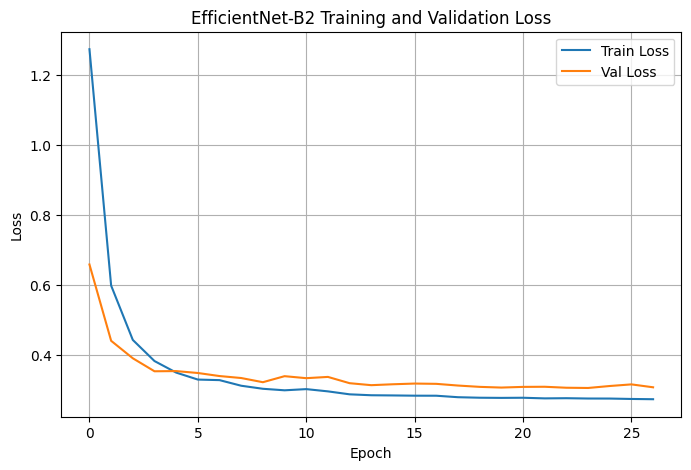

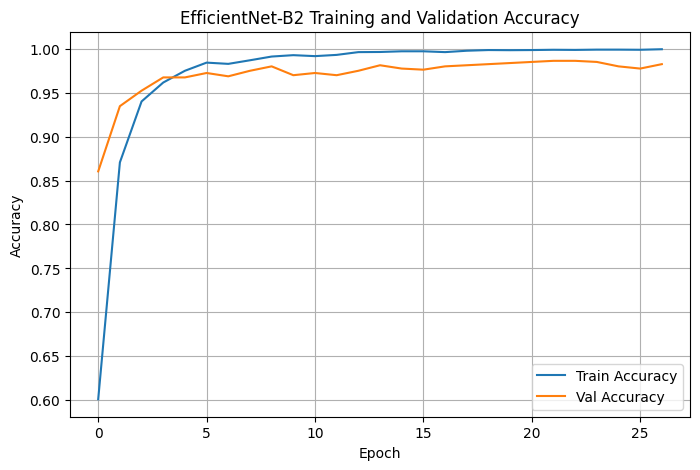

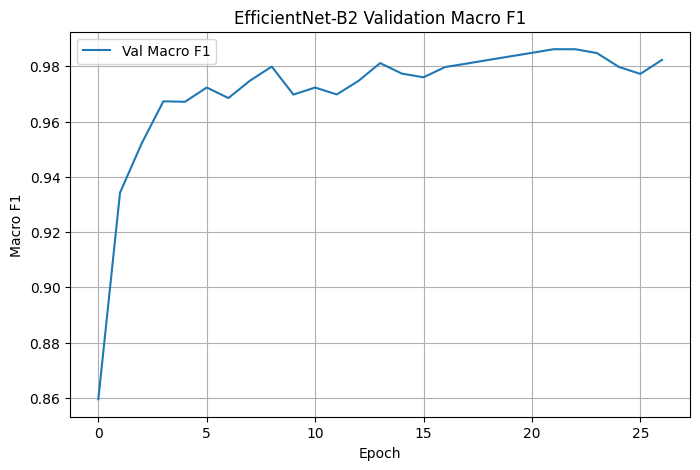

Loss curve saved: /content/outputs_b2_v4/loss_curve.png
Accuracy curve saved: /content/outputs_b2_v4/accuracy_curve.png
Val macro F1 curve saved: /content/outputs_b2_v4/val_macro_f1_curve.png


In [ ]:
history_path = OUTPUT_DIR / "training_history.json"

with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=4)

print("Training history saved:", history_path)

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B2 Training and Validation Loss")
plt.legend()
plt.grid(True)

loss_curve_path = OUTPUT_DIR / "loss_curve.png"
plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet-B2 Training and Validation Accuracy")
plt.legend()
plt.grid(True)

accuracy_curve_path = OUTPUT_DIR / "accuracy_curve.png"
plt.savefig(accuracy_curve_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["val_macro_f1"], label="Val Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("EfficientNet-B2 Validation Macro F1")
plt.legend()
plt.grid(True)

f1_curve_path = OUTPUT_DIR / "val_macro_f1_curve.png"
plt.savefig(f1_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss curve saved:", loss_curve_path)
print("Accuracy curve saved:", accuracy_curve_path)
print("Val macro F1 curve saved:", f1_curve_path)

Testing:   0%|          | 0/25 [00:00<?, ?batch/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Test Accuracy: 0.9698492462311558
Test Macro Precision: 0.9709954693856788
Test Macro Recall: 0.9698958333333333
Test Macro F1: 0.9699691195571378

Classification Report:
               precision    recall  f1-score   support

          SUV       0.96      0.94      0.95       100
          VAN       0.99      1.00      1.00       100
STATION_WAGON       0.97      1.00      0.99       100
        MICRO       0.98      0.98      0.98        96
   OPEN_WHEEL       1.00      1.00      1.00       100
        SEDAN       0.99      0.90      0.94       100
    HATCHBACK       0.88      0.95      0.91       100
      PICK_UP       1.00      0.99      0.99       100

     accuracy                           0.97       796
    macro avg       0.97      0.97      0.97       796
 weighted avg       0.97      0.97      0.97       796



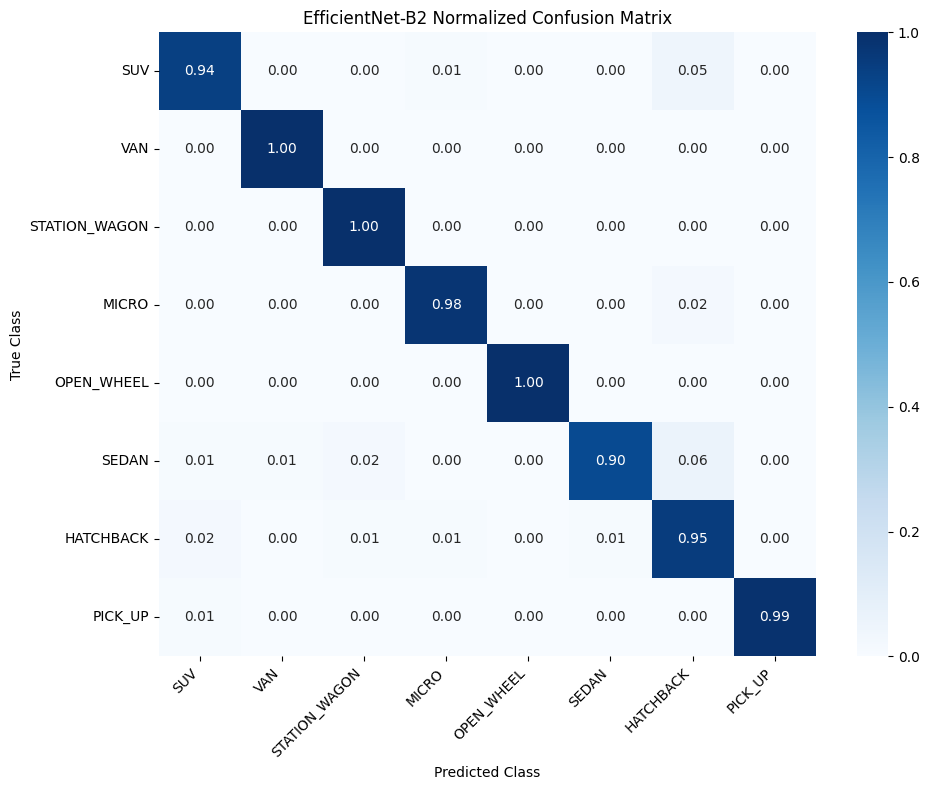

Confusion matrix saved: /content/outputs_b2_v4/normalized_confusion_matrix.png


In [ ]:
best_model = create_model(
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE
)

best_model.load_state_dict(
    torch.load(BEST_MODEL_PATH, map_location=DEVICE)
)

best_model = best_model.to(DEVICE)
best_model.eval()

all_true = []
all_pred = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing", unit="batch"):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                outputs = best_model(images)
        else:
            outputs = best_model(images)

        preds = torch.argmax(outputs, dim=1)

        all_true.extend(labels.detach().cpu().numpy())
        all_pred.extend(preds.detach().cpu().numpy())

test_acc = accuracy_score(all_true, all_pred)
test_precision = precision_score(all_true, all_pred, average="macro", zero_division=0)
test_recall = recall_score(all_true, all_pred, average="macro", zero_division=0)
test_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)

print("Test Accuracy:", test_acc)
print("Test Macro Precision:", test_precision)
print("Test Macro Recall:", test_recall)
print("Test Macro F1:", test_f1)

report = classification_report(
    all_true,
    all_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    zero_division=0,
    output_dict=True
)

report_text = classification_report(
    all_true,
    all_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    zero_division=0
)

print("\nClassification Report:")
print(report_text)

with open(OUTPUT_DIR / "test_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

with open(OUTPUT_DIR / "test_classification_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=4)

metrics = {
    "model_name": "efficientnet_b2",
    "best_val_macro_f1": best_val_f1,
    "accuracy": test_acc,
    "macro_precision": test_precision,
    "macro_recall": test_recall,
    "macro_f1": test_f1
}

with open(OUTPUT_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4)

cm = confusion_matrix(
    all_true,
    all_pred,
    labels=list(range(NUM_CLASSES)),
    normalize="true"
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cmap="Blues"
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("EfficientNet-B2 Normalized Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = OUTPUT_DIR / "normalized_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved:", cm_path)

In [ ]:
model_size_mb = BEST_MODEL_PATH.stat().st_size / (1024 * 1024)

print(f"Best model size: {model_size_mb:.2f} MB")

if model_size_mb > 95:
    print("Uyari: Model dosyasi 95 MB sinirini asiyor.")
else:
    print("Model dosyasi 95 MB siniri altinda.")

Best model size: 29.86 MB
Model dosyasi 95 MB siniri altinda.


In [ ]:
from PIL import Image

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

prediction_transform = eval_transform

def predict_single_image(image_path, model, device):
    image = Image.open(image_path).convert("RGB")
    tensor = prediction_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                outputs = model(tensor)
        else:
            outputs = model(tensor)

        probabilities = torch.softmax(outputs, dim=1)
        predicted_index = torch.argmax(probabilities, dim=1).item()

    predicted_label = predicted_index + 1

    return predicted_label


def create_preds_txt(input_dir, output_file):
    input_dir = Path(input_dir)
    output_file = Path(output_file)

    image_paths = [
        p for p in input_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
    ]

    image_paths = sorted(image_paths, key=lambda p: p.name)

    seen_names = set()
    duplicate_names = set()

    with open(output_file, "w", encoding="utf-8") as f:
        for image_path in tqdm(image_paths, desc="Creating preds.txt"):
            if image_path.name in seen_names:
                duplicate_names.add(image_path.name)
                print("Uyari: Ayni dosya adi tekrar ediyor:", image_path.name)

            seen_names.add(image_path.name)

            try:
                predicted_label = predict_single_image(
                    image_path=image_path,
                    model=best_model,
                    device=DEVICE
                )

                f.write(f"{image_path.name} | Pred: {predicted_label}\n")

            except Exception as e:
                print("Uyari: Gorsel tahmin edilemedi:", image_path, e)

    print("preds.txt olusturuldu:", output_file)
    print("Tahmin edilen gorsel sayisi:", len(image_paths))
    print("Tekrar eden dosya adi sayisi:", len(duplicate_names))


preds_path = OUTPUT_DIR / "preds.txt"
create_preds_txt(TEST_DIR, preds_path)

Creating preds.txt:   0%|          | 0/796 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


preds.txt olusturuldu: /content/outputs_b2_v4/preds.txt
Tahmin edilen gorsel sayisi: 796
Tekrar eden dosya adi sayisi: 0


In [ ]:
import zipfile
from pathlib import Path

RESULT_ZIP_PATH = Path("/content/car_body_results_b2_v4.zip")

if RESULT_ZIP_PATH.exists():
    RESULT_ZIP_PATH.unlink()

with zipfile.ZipFile(RESULT_ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zipf:
    for folder in [MODEL_DIR, OUTPUT_DIR]:
        for file_path in folder.rglob("*"):
            if file_path.is_file():
                arcname = file_path.relative_to(Path("/content"))
                zipf.write(file_path, arcname)

print("Sonuc zip hazir:", RESULT_ZIP_PATH)
print("Zip boyutu MB:", RESULT_ZIP_PATH.stat().st_size / (1024 * 1024))

Sonuc zip hazir: /content/car_body_results_b2_v4.zip
Zip boyutu MB: 28.077866554260254


In [ ]:
from google.colab import files

files.download("/content/car_body_results_b2_v4.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>